### Krótki opis cech i zbioru

Zbiór danych Diamonds składa się z 53 940 rekordów i 10 kolumn, które opisują parametry fizyczne, jakość oraz cenę diamentów:

price (cena) – zmienna docelowa (target) w dolarach amerykańskich ($326 - $18,823).

carat (waga) – masa diamentu w karatach (0.2 - 5.01).

cut (szlif) – jakość szlifu określana w 5 kategoriach (Fair, Good, Very Good, Premium, Ideal).

color (kolor) – odcień diamentu w skali od J (najgorszy) do D (najlepszy).

clarity (przejrzystość) – czystość diamentu (kategorie od I1 – najgorsza, po IF – najlepsza).

x (długość) – długość diamentu w mm.

y (szerokość) – szerokość diamentu w mm.

z (głębokość) – głębokość diamentu w mm.

depth (głębokość całkowita w %) – proporcja obliczana na podstawie z/mean(x, y).

table (rozmiar tafli) – szerokość górnej płaszczyzny diamentu w stosunku do najszerszego punktu.

**Link do zbioru w kaggle: https://www.kaggle.com/datasets/shivam2503/diamonds/discussion/262522**

### Montowanie Google Drive
Najpierw zamontuję dysk Google Drive, aby uzyskać dostęp do zbioru danych.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Instalacja PySpark
Następnie zainstaluję bibliotekę PySpark, która jest niezbędna do pracy z ramkami danych Spark (Spark DataFrames).

In [33]:
!pip install pyspark

### Inicjalizacja sesji Spark
Teraz zainicjuję SparkSession, aby aktywować funkcjonalności środowiska Spark.

In [34]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .appName("DiamondsCSVLoader")\
    .getOrCreate()

### Wczytanie zbioru danych jako Spark DataFrame
Na koniec wczytam plik diamonds.csv do struktury Spark DataFrame. Użyję parametru header=True, aby potraktować pierwszy wiersz jako nazwy kolumn, oraz inferSchema=True, aby automatycznie wykryć typy danych.

In [35]:
file_path = '/content/drive/MyDrive/diamonds.csv'
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

display(df_spark.limit(5).toPandas())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


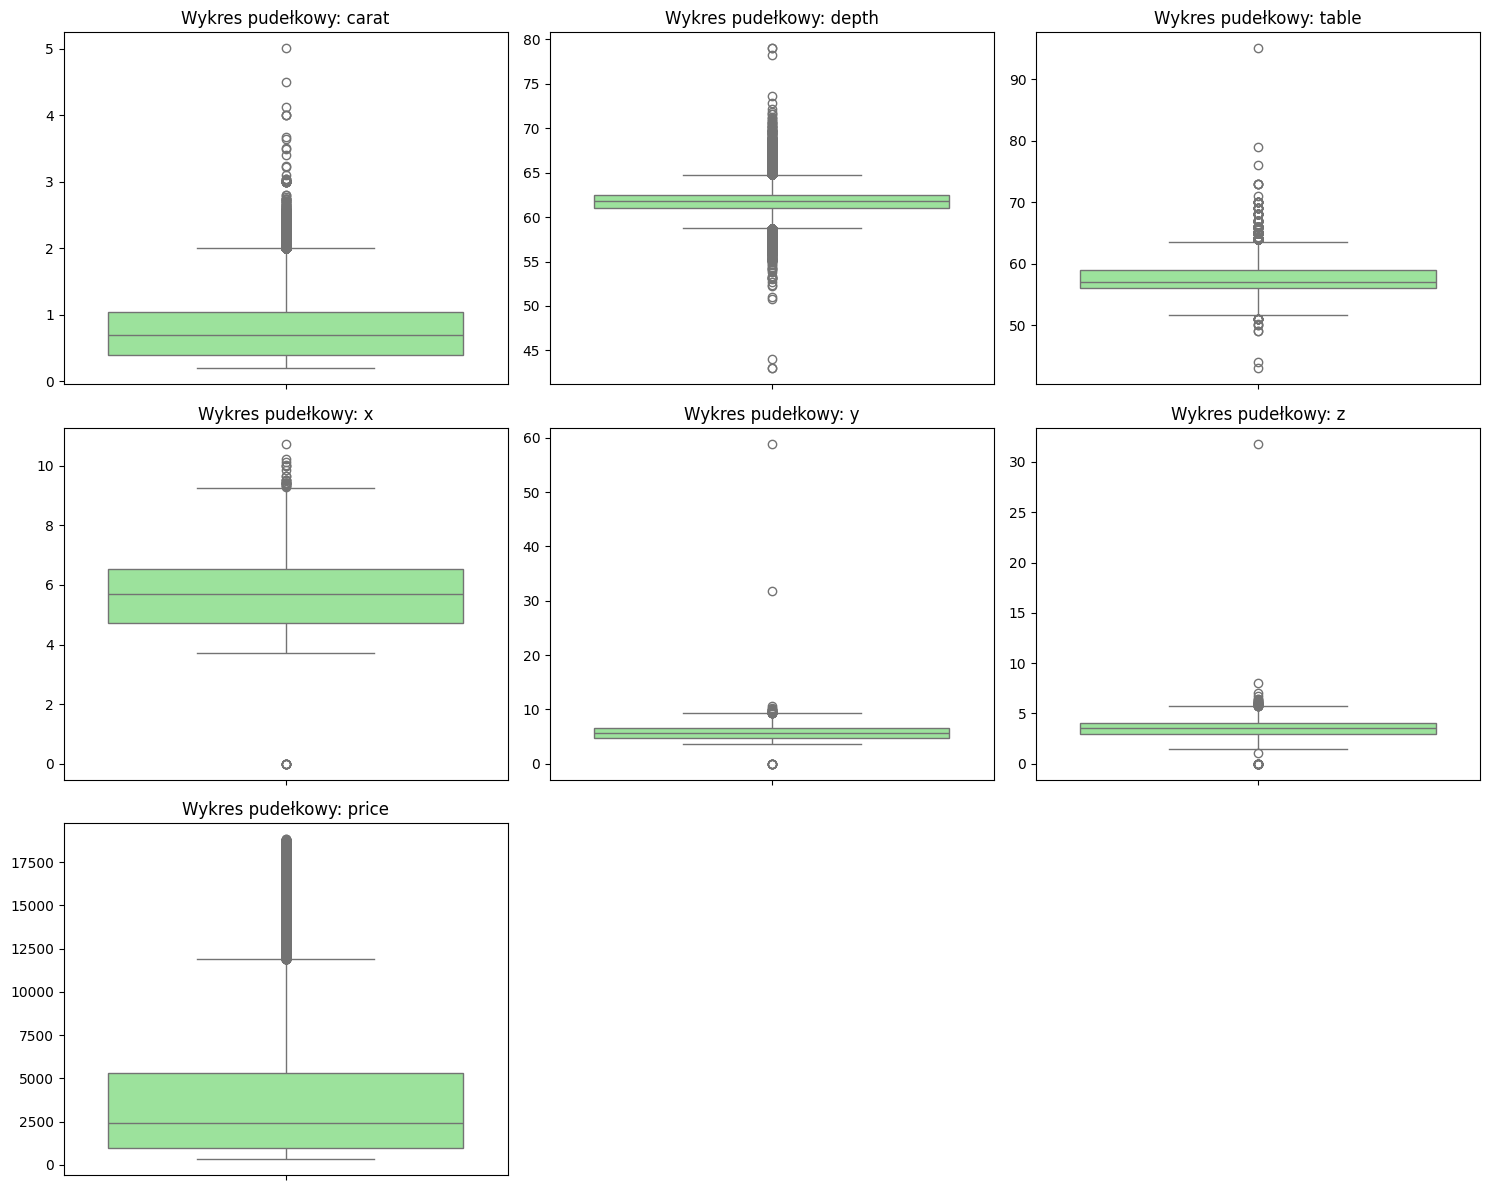

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konwersja ramki Spark DataFrame do Pandas (korzystamy z oczyszczonej lub oryginalnej)
df_pd = df_spark.toPandas()

numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_pd[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Wykres pudełkowy: {col}')
    axes[i].set_ylabel('')

# Ukrywamy puste osie
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Usuwanie wartości odstających (Outlierów) za pomocą rozstępu międzykwartylowego (IQR)

Przed przystąpieniem do inżynierii cech dla modelu uczenia maszynowego, usunę wartości odstające z kolumn numerycznych (carat, depth, table, x, y, z) za pomocą metody IQR. W wyniku tego procesu powstanie nowy DataFrame o nazwie df_no_outliers, który posłuży jako wejście do potoku uczenia maszynowego (ML pipeline).

In [37]:
from pyspark.sql.functions import col

df_no_outliers = df_spark # Zaczynamy od oryginalnej ramki danych
initial_row_count = df_spark.count()
print(f"Początkowa liczba wierszy: {initial_row_count}")

cols_for_outlier_removal = ['carat', 'depth', 'table', 'x', 'y', 'z']

for i in cols_for_outlier_removal:
    # Obliczanie Q1 i Q3
    # Używamy approxQuantile dla lepszej wydajności na dużych zbiorach. Błąd względny 0.01.
    quantiles = df_no_outliers.approxQuantile(i, [0.25, 0.75], 0.01)
    Q1 = quantiles[0]
    Q3 = quantiles[1]
    IQR = Q3 - Q1

    # Obliczanie dolnej i górnej granicy
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Filtrowanie ramki danych w celu usunięcia wartości odstających dla obecnej kolumny
    df_no_outliers = df_no_outliers.filter(
        (col(i) >= lower_bound) & (col(i) <= upper_bound)
    )
    print(f"Liczba wierszy po usunięciu wartości odstających dla '{i}': {df_no_outliers.count()}")

final_row_count = df_no_outliers.count()
print(f"Końcowa liczba wierszy po usunięciu wartości odstających dla wszystkich kolumn: {final_row_count}")
print(f"Całkowita liczba usuniętych wierszy: {initial_row_count - final_row_count}")

df_spark = df_no_outliers # Aktualizacja głównej ramki danych do nowej wersji bez wartości odstających

Początkowa liczba wierszy: 53940
Liczba wierszy po usunięciu wartości odstających dla 'carat': 51778
Liczba wierszy po usunięciu wartości odstających dla 'depth': 49463
Liczba wierszy po usunięciu wartości odstających dla 'table': 49106
Liczba wierszy po usunięciu wartości odstających dla 'x': 49100
Liczba wierszy po usunięciu wartości odstających dla 'y': 49099
Liczba wierszy po usunięciu wartości odstających dla 'z': 49091
Końcowa liczba wierszy po usunięciu wartości odstających dla wszystkich kolumn: 49091
Całkowita liczba usuniętych wierszy: 4849


### Przygotowanie danych do uczenia maszynowego

Przed wytrenowaniem modelu RandomForest, musimy przygotować dane. Obejmuje to:
1.  Identyfikację cech i zmiennej docelowej: Naszą zmienną docelową (target) jest price.
2.  Przetwarzanie cech kategorycznych: Spark ML wymaga cech w formacie numerycznym. Kolumny kategoryczne (cut, color, clarity) zostaną zakodowane za pomocą StringIndexer oraz OneHotEncoder.
3.  Asemblację wektorów: Wszystkie kolumny cech (numeryczne oraz zakodowane kategoryczne) zostaną połączone w jedną wektorową kolumnę o nazwie features przy użyciu narzędzia VectorAssembler.

In [38]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# Identyfikacja kolumn kategorycznych i numerycznych
categorical_cols = ['cut', 'color', 'clarity']
numerical_cols = [col for col in df_spark.columns if col not in categorical_cols + ['price']]

# Etap 1: Indeksowanie cech kategorycznych
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep")
    for col in categorical_cols
]

# Etap 2: Kodowanie One-Hot zindeksowanych cech kategorycznych
encoders = [
    OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded")
    for col in categorical_cols
]

# Etap 3: Złożenie wszystkich cech w jeden wektor
assembler_inputs = [col + "_encoded" for col in categorical_cols] + numerical_cols
vector_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Tworzenie potoku (pipeline) w celu połączenia wszystkich etapów transformacji
pipeline = Pipeline(stages=indexers + encoders + [vector_assembler])

# Dopasowanie potoku do danych i ich transformacja
df_transformed = pipeline.fit(df_spark).transform(df_spark)

display(df_transformed.select('features', 'price').limit(5).toPandas())

,features,price
0,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",326
1,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",326
2,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",334
3,"(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",335
4,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",336


### Podział danych na zbiór treningowy i testowy
Teraz podzielę przekształcony DataFrame na zbiór treningowy i testowy, aby ocenić wydajność modelu na nowych, niewidzianych wcześniej danych.

In [39]:
# Podział danych na zbiór treningowy i testowy (80% danych treningowych, 20% testowych)
(training_data, testing_data) = df_transformed.randomSplit([0.8, 0.2], seed=42)

print(f"Liczba wierszy w zbiorze treningowym: {training_data.count()}")
print(f"Liczba wierszy w zbiorze testowym: {testing_data.count()}")

Liczba wierszy w zbiorze treningowym: 39222
Liczba wierszy w zbiorze testowym: 9869


### Trenowanie modelu RandomForestRegressor
Następnie wytrenuję model RandomForestRegressor przy użyciu przygotowanych danych treningowych. Ponieważ cena (price) jest zmienną ciągłą, użycie regresji jest tu najbardziej odpowiednie.

In [40]:
from pyspark.ml.regression import RandomForestRegressor

# Inicjalizacja RandomForestRegressor
rf_regressor = RandomForestRegressor(featuresCol="features", labelCol="price", seed=42)

# Trening modelu
rf_model = rf_regressor.fit(training_data)

print("RandomForestRegressor model wytrenowany pomyślnie")

RandomForestRegressor model wytrenowany pomyślnie


### Generowanie predykcji i ewaluacja modelu
Na koniec użyję wytrenowanego modelu, aby wygenerować predykcje na zbiorze testowym. Jego wydajność ocenię za pomocą metryk takich jak błąd średniokwadratowy (RMSE) oraz współczynnik determinacji (R2).

In [41]:
from pyspark.ml.evaluation import RegressionEvaluator

# Dokonanie predykcji na danych testowych
predictions = rf_model.transform(testing_data)

# Wybranie przykładowych predykcji i wartości rzeczywistych do wyświetlenia
display(predictions.select('price', 'prediction', 'features').limit(10).toPandas())

# Ewaluacja modelu przy użyciu metryk RMSE (pierwiastek błędu średniokwadratowego) i R-squared (R2)
evaluator_rmse = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(predictions)
print(f"Pierwiastek błędu średniokwadratowego (RMSE) na danych testowych = {rmse:.4f}")

evaluator_r2 = RegressionEvaluator(
    labelCol="price", predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)
print(f"Współczynnik determinacji (R-squared / R2) na danych testowych = {r2:.4f}")

,price,prediction,features
0,367,622.233482,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
1,367,616.303593,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
2,367,616.303593,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
3,386,615.813970,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,386,610.100372,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
5,470,615.813970,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
6,465,616.303593,"(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
7,442,615.813970,"(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
8,326,622.233482,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
9,586,622.233482,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."


Pierwiastek błędu średniokwadratowego (RMSE) na danych testowych = 1051.3868
Współczynnik determinacji (R-squared / R2) na danych testowych = 0.9059


### Wsadowe trenowanie modelu RandomForestRegressor (Batch Training)
Aby zademonstrować trening wsadowy i zaobserwować wydajność modelu przy różnej ilości danych, wytrenuję model RandomForestRegressor na stopniowo powiększanych podzbiorach danych treningowych (training_data). Dla każdego wsadu (batcha) zostanie wytrenowany nowy model, który następnie poddam ocenię na zbiorze testowym (testing_data).

In [42]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = SparkSession.builder\
    .appName("DiamondsCSVLoader")\
    .getOrCreate()

file_path = '/content/drive/MyDrive/diamonds.csv'
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

df_no_outliers = df_spark # Zaczynamy od oryginalnej ramki danych
initial_row_count = df_spark.count()
print(f"Początkowa liczba wierszy: {initial_row_count}")

cols_for_outlier_removal = ['carat', 'depth', 'table', 'x', 'y', 'z']

for i in cols_for_outlier_removal:
    # Obliczanie Q1 i Q3
    # Używamy approxQuantile dla lepszej wydajności na dużych zbiorach. Błąd względny 0.01.
    quantiles = df_no_outliers.approxQuantile(i, [0.25, 0.75], 0.01)
    Q1 = quantiles[0]
    Q3 = quantiles[1]
    IQR = Q3 - Q1

    # Obliczanie dolnej i górnej granicy
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Filtrowanie ramki danych w celu usunięcia wartości odstających dla obecnej kolumny
    df_no_outliers = df_no_outliers.filter(
        (col(i) >= lower_bound) & (col(i) <= upper_bound)
    )
    print(f"Liczba wierszy po usunięciu wartości odstających dla '{i}': {df_no_outliers.count()}")

final_row_count = df_no_outliers.count()
print(f"Końcowa liczba wierszy po usunięciu wartości odstających dla wszystkich kolumn: {final_row_count}")
print(f"Całkowita liczba usuniętych wierszy: {initial_row_count - final_row_count}")

df_spark = df_no_outliers # Aktualizacja głównej ramki danych do nowej wersji bez wartości odstających

# Identyfikacja kolumn kategorycznych i numerycznych
categorical_cols = ['cut', 'color', 'clarity']
numerical_cols = [col for col in df_spark.columns if col not in categorical_cols + ['price']]

# Etap 1: Indeksowanie cech kategorycznych
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep")
    for col in categorical_cols
]

# Etap 2: Kodowanie One-Hot zindeksowanych cech kategorycznych
encoders = [
    OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded")
    for col in categorical_cols
]

# Etap 3: Złożenie wszystkich cech w jeden wektor
assembler_inputs = [col + "_encoded" for col in categorical_cols] + numerical_cols
vector_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Tworzenie potoku (pipeline) w celu połączenia wszystkich etapów transformacji
pipeline = Pipeline(stages=indexers + encoders + [vector_assembler])

# Dopasowanie potoku do danych i ich transformacja
df_transformed = pipeline.fit(df_spark).transform(df_spark)

# Podział danych na zbiór treningowy i testowy (80% trening, 20% test)
(training_data, testing_data) = df_transformed.randomSplit([0.8, 0.2], seed=42)

# Zdefiniowanie proporcji danych treningowych do użycia dla każdego wsadu
batch_proportions = [0.2, 0.4, 0.6, 0.8, 1.0]

print("Rozpoczynanie treningu wsadowego...")

for prop in batch_proportions:
    print(f"\n--- Trenowanie na {prop*100:.0f}% danych treningowych ---")

    # Losowanie wsadu (batcha) z danych treningowych
    # Argument `seed` zapewnia powtarzalność losowania dla danej proporcji
    current_training_batch = training_data.sample(withReplacement=False, fraction=prop, seed=42)
    print(f"Rozmiar wsadu: {current_training_batch.count()} wierszy")

    # Inicjalizacja i trenowanie nowego modelu RandomForestRegressor dla tego wsadu
    rf_regressor_batch = RandomForestRegressor(featuresCol="features", labelCol="price", seed=42)
    rf_model_batch = rf_regressor_batch.fit(current_training_batch)

    # Dokonywanie predykcji na pełnym zbiorze testowym przy użyciu modelu z obecnego wsadu (z pomiarem czasu)
    start_pred_time = time.time()

    batch_predictions = rf_model_batch.transform(testing_data)
    batch_predictions.count()  # Wymuszenie wykonania operacji (tzw. akcja w Sparku, by uniknąć leniwej ewaluacji)

    end_pred_time = time.time()
    prediction_time = end_pred_time - start_pred_time

    # Ewaluacja modelu
    evaluator_rmse_batch = RegressionEvaluator(
        labelCol="price", predictionCol="prediction", metricName="rmse")
    rmse_batch = evaluator_rmse_batch.evaluate(batch_predictions)

    evaluator_r2_batch = RegressionEvaluator(
        labelCol="price", predictionCol="prediction", metricName="r2")
    r2_batch = evaluator_r2_batch.evaluate(batch_predictions)

    print(f"Czas predykcji dla tego wsadu: {prediction_time:.4f} sekund")
    print(f"RMSE na danych testowych dla tego wsadu: {rmse_batch:.4f}")
    print(f"Współczynnik R-squared (R2) na danych testowych dla tego wsadu: {r2_batch:.4f}")

Początkowa liczba wierszy: 53940
Liczba wierszy po usunięciu wartości odstających dla 'carat': 51778
Liczba wierszy po usunięciu wartości odstających dla 'depth': 49463
Liczba wierszy po usunięciu wartości odstających dla 'table': 49106
Liczba wierszy po usunięciu wartości odstających dla 'x': 49100
Liczba wierszy po usunięciu wartości odstających dla 'y': 49099
Liczba wierszy po usunięciu wartości odstających dla 'z': 49091
Końcowa liczba wierszy po usunięciu wartości odstających dla wszystkich kolumn: 49091
Całkowita liczba usuniętych wierszy: 4849
Rozpoczynanie treningu wsadowego...

--- Trenowanie na 20% danych treningowych ---
Rozmiar wsadu: 7862 wierszy
Czas predykcji dla tego wsadu: 1.1552 sekund
RMSE na danych testowych dla tego wsadu: 1086.0934
Współczynnik R-squared (R2) na danych testowych dla tego wsadu: 0.8996

--- Trenowanie na 40% danych treningowych ---
Rozmiar wsadu: 15706 wierszy
Czas predykcji dla tego wsadu: 0.6179 sekund
RMSE na danych testowych dla tego wsadu: 107

### Porównanie moedlu Gradient Boosting Tree do Random Forest

1. **Spadek błędu (RMSE)**



*   Błąd średniokwadratowy (RMSE) mówi nam, o ile średnio nasz model myli się w swoich przewidywaniach.
*   Random Forest mylił się średnio o 1051 jednostek.
*   Gradient Boosting (GBT) zredukował ten błąd niemal o połowę, do 530! W kontekście wyceny drogocennych kamieni jest to kolosalna różnica, która sprawia, że model GBT jest znacznie bardziej godny zaufania przy rzeczywistych wycenach.






2. **Prawie perfekcyjne dopasowanie (R2)**

    Współczynnik determinacji (R2) określa, jaki procent wariancji (zmienności) ceny diamentów jest poprawnie tłumaczony przez model.

    Wynik Random Forest na poziomie 0.9059 (ok. 90.6%) był już bardzo solidny.

    Jednak wynik GBT na poziomie 0.9760 (ok. 97.6%) jest wręcz rewelacyjny. Oznacza to, że algorytm potrafił wyłapać bardzo subtelne, nieliniowe zależności (np. jak specyficzne kombinacje czystości, koloru i karatów wpływają na skoki cenowe) i niemal idealnie dopasował się do danych testowych.

3. **Koszt sukcesu: Czas treningu**

    Model GBT potrzebował 42.38 sekund na wytrenowanie.

    Gradient Boosting buduje drzewa decyzyjne w sposób sekwencyjny — każde kolejne drzewo uczy się na błędach poprzedniego. Dlatego nie można tego procesu w pełni zrównoleglić, co wydłuża czas treningu w porównaniu do Random Forest.


In [43]:
import time
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

print("Rozpoczęcie treningu Gradient Boosting Tree (GBT)...")

# Inicjalizacja modelu GBTRegressor
gbt_regressor = GBTRegressor(featuresCol="features", labelCol="price", maxIter=50, seed=42)

start_time_gbt = time.time()
gbt_model = gbt_regressor.fit(training_data)
end_time_gbt = time.time()

training_duration_gbt = end_time_gbt - start_time_gbt

# Predykcja na zbiorze testowym
gbt_predictions = gbt_model.transform(testing_data)

# Ewaluacja
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse_gbt = evaluator_rmse.evaluate(gbt_predictions)
r2_gbt = evaluator_r2.evaluate(gbt_predictions)

print("\n=== PORÓWNANIE ALGORYTMÓW ===")
print(f"[Random Forest]     RMSE: {rmse:.4f},  R2: {r2:.4f}")
print(f"[Gradient Boosting] RMSE: {rmse_gbt:.4f},  R2: {r2_gbt:.4f}")
print(f"\nCzas treningu GBT: {training_duration_gbt:.2f} sekund")

Rozpoczęcie treningu Gradient Boosting Tree (GBT)...

=== PORÓWNANIE ALGORYTMÓW ===
[Random Forest]     RMSE: 1051.3868,  R2: 0.9059
[Gradient Boosting] RMSE: 530.9347,  R2: 0.9760

Czas treningu GBT: 31.06 sekund


### Top 10 cech dominujących

/tmp/ipykernel_16484/2416775555.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Znaczenie', y='Cecha', data=feature_importance_df.head(10), palette='magma')


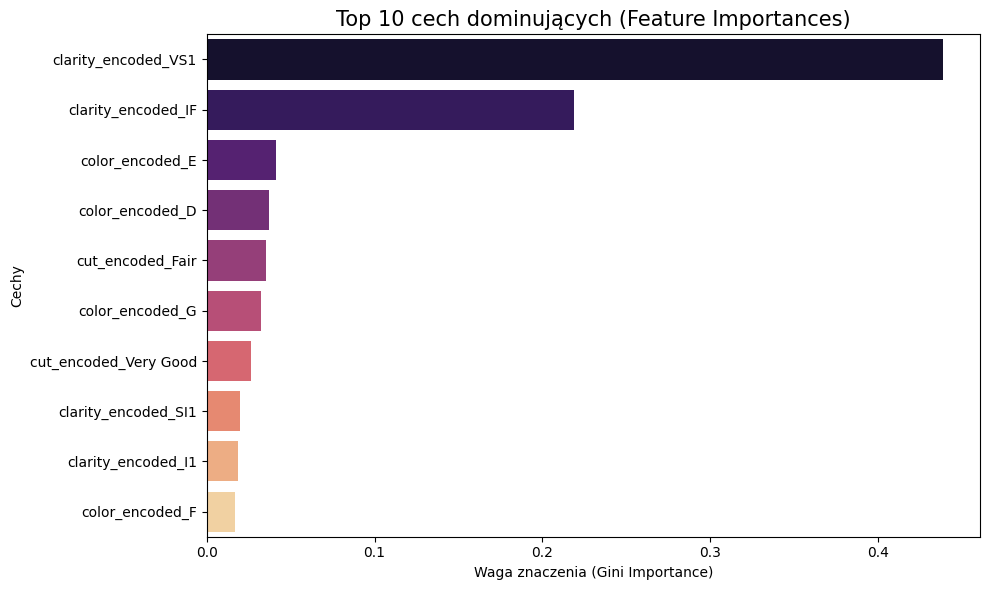

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

attrs = df_transformed.schema["features"].metadata["ml_attr"]["attrs"]
feature_names = []
for attr_type in ['numeric', 'binary']:
    if attr_type in attrs:
        feature_names += [item['name'] for item in attrs[attr_type]]

# Zbieramy współczynniki z wytrenowanego modelu GBT (lub Random Forest: rf_model.featureImportances)
importances = gbt_model.featureImportances.toArray()

# Utworzenie DataFrame Pandas do wygodnego wizualizowania
feature_importance_df = pd.DataFrame({
    'Cecha': feature_names,
    'Znaczenie': importances
}).sort_values(by='Znaczenie', ascending=False)

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
sns.barplot(x='Znaczenie', y='Cecha', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 cech dominujących (Feature Importances)', fontsize=15)
plt.xlabel('Waga znaczenia (Gini Importance)')
plt.ylabel('Cechy')
plt.tight_layout()
plt.show()

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

df_pd = df_spark.toPandas()

numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

### **Analiza rozkładów zmiennych numerycznych (Histogramy)**

1. **Silna prawoskośność ceny (price)**

    Rozkład zmiennej docelowej (ceny) jest wysoce prawoskośny. Oznacza to, że zdecydowana większość diamentów w naszym zbiorze znajduje się w niższych przedziałach cenowych, a wykres charakteryzuje się tzw. "długim ogonem" ciągnącym się w stronę bardzo wysokich kwot. Jest to typowe zjawisko dla dóbr luksusowych i potwierdza, że ekstremalnie drogie kamienie są rzadkością.

2. **Psychologia rynku widoczna w wadze (carat)**

    Histogram dla wagi wyrażonej w karatach nie jest gładki - charakteryzuje się licznymi, lokalnymi maksimami. Występują one na wartościach, takich jak 0.3, 0.5, 0.7, 1.0, 1.2 czy 1.5 karata.

3. **Odzwierciedlenie wagi w wymiarach (x, y, z)**

    Rozkłady dla wymiarów fizycznych (długość, szerokość, głębokość w mm) są wielowierzchołkowe. Ich kształt mocno naśladuje piki widoczne na histogramie karatów. Jest to wizualne potwierdzenie silnej współliniowości, którą zaobserwujemy na heatmapie - skoki w liczebności konkretnych wag diamentów naturalnie pociągają za sobą skoki w liczebności odpowiadających im wymiarów.

4. **Rozkłady zmiennych proporcjonalnych (depth, table)**

    Zmienne określające proporcje szlifu mają rozkład najbardziej zbliżony do normalnego. Pokazuje to, że zdecydowana większość kamieni na rynku trzyma się pewnych standardowych, uznawanych za optymalne proporcji (np. depth oscylujące najczęściej w okolicach 61-62%). W przypadku zmiennej table widać wyraźne schodkowanie - wynika to ze specyfiki branży, w której ten parametr jest najczęściej zaokrąglany do pełnych liczb (np. 55, 56, 57).

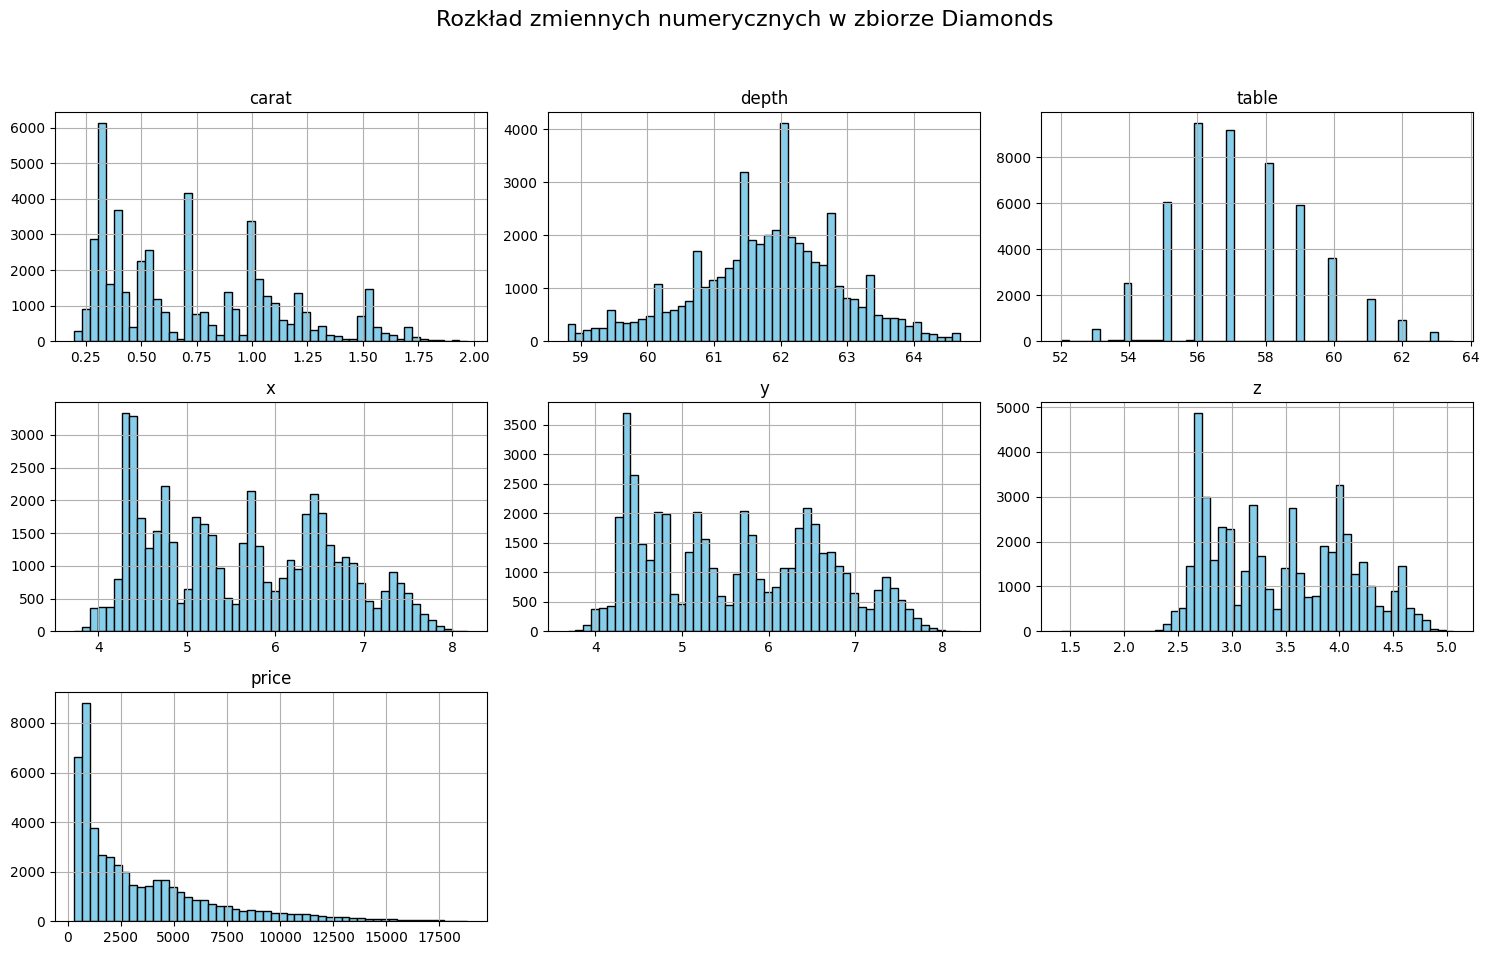

In [46]:
df_pd[numerical_cols].hist(bins=50, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Rozkład zmiennych numerycznych w zbiorze Diamonds', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Analiza zmiennych kategorycznych (Wykresy pudełkowe)**

1. **Uzasadnienie usunięcia wartości odstających (Outlierów)**

    Na każdym z trzech wykresów widać ogromną liczbę punktów znajdujących się powyżej górnych wąsów (tzw. outliery). Reprezentują one diamenty o anomalnie wysokich cenach w stosunku do średniej w swoich kategoriach. Zignorowanie ich sprawiłoby, że nasz model uczyłby się na szumie i skrajnych przypadkach. Stanowi to główny argument za zastosowaniem przez nas metody IQR (Interquartile Range) na etapie preprocessingu, aby "oczyścić" zbiór treningowy.

2. **Uzasadnienie wyboru modelu Random Forest**

    Powyższe anomalie idealnie udowadniają, że wycena diamentu to problem wielowymiarowy. Prosta analiza jednej cechy daje błędne wnioski. Potrzebowaliśmy algorytmu, który potrafi wychwycić złożone, nieliniowe interakcje między szlifem, kolorem, czystością a ostateczną wagą kamienia. Zastosowanie modelu Random Forest Regressor było więc naturalnym i w pełni uzasadnionym wyborem do tego zadania.

3. **Na pierwszy rzut oka wykresy pokazują nielogiczne zależności. Przykładowo:**


*   Diamenty o idealnym szlifie (Ideal) mają niższą medianę ceny niż te o szlifie Premium.
*   Najczystsze barwy (np. D, E) wykazują niższą średnią cenę niż barwy gorszej jakości (J).
*   Diamenty nieskazitelnie czyste (IF) są statystycznie tańsze niż te z widocznymi skazami (SI2).



    
    
    
    Z czego to wynika? Z tzw. Paradoksu Simpsona. Analizujemy tu tylko jedną cechę w oderwaniu od reszty. W rzeczywistości diamenty o absolutnie perfekcyjnych parametrach szlifu, barwy i czystości są w zbiorze przeważnie bardzo małe (mała liczba karatów). Z kolei diamenty gorszej jakości nadrabiają swoją cenę dużą wagą.

/tmp/ipykernel_16484/2834490457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_pd, x='cut', y='price', palette='Set2')
/tmp/ipykernel_16484/2834490457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_pd, x='color', y='price', palette='Set2')
/tmp/ipykernel_16484/2834490457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], data=df_pd, x='clarity', y='price', palette='Set2')


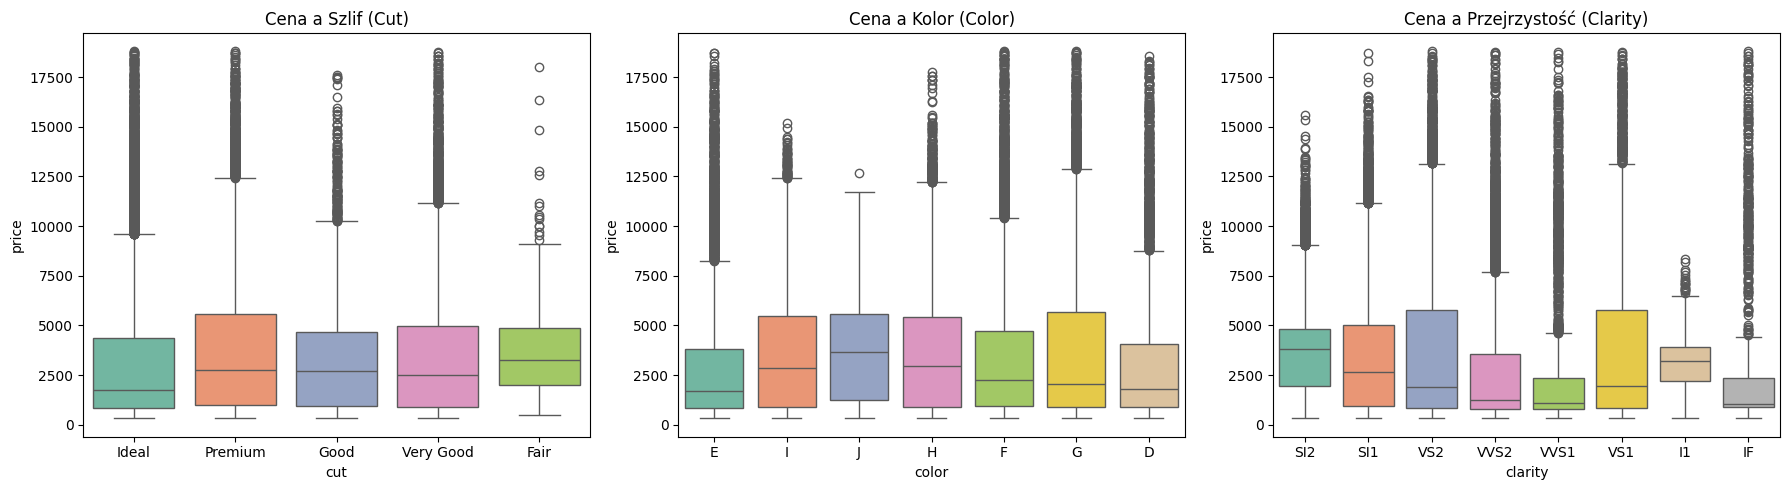

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], data=df_pd, x='cut', y='price', palette='Set2')
axes[0].set_title('Cena a Szlif (Cut)')

sns.boxplot(ax=axes[1], data=df_pd, x='color', y='price', palette='Set2')
axes[1].set_title('Cena a Kolor (Color)')

sns.boxplot(ax=axes[2], data=df_pd, x='clarity', y='price', palette='Set2')
axes[2].set_title('Cena a Przejrzystość (Clarity)')

plt.tight_layout()
plt.show()

### **Analiza Heatmapy Korelacji – Główne Wnioski**
Najsilniejszy wpływ na cenę (price):



*   Zdecydowanie najważniejszym czynnikiem determinującym cenę jest waga diamentu, czyli carat. Współczynnik korelacji wynosi tu aż 0.91, co wskazuje na bardzo silną, dodatnią zależność (im cięższy diament, tym wyższa cena).
*   Wymiary fizyczne diamentu, czyli długość (x), szerokość (y) oraz głębokość w mm (z), również wykazują bardzo silną korelację z ceną (wszystkie na poziomie 0.87).


Silna współliniowość (Multicollinearity):



*   Zmienne carat, x, y oraz z są ze sobą skorelowane niemal perfekcyjnie. Współczynniki korelacji między nimi oscylują w granicach 0.98 – 1.00.

Jest to całkowicie logiczne z fizycznego punktu widzenia: diament o większej masie musi mieć większe wymiary.

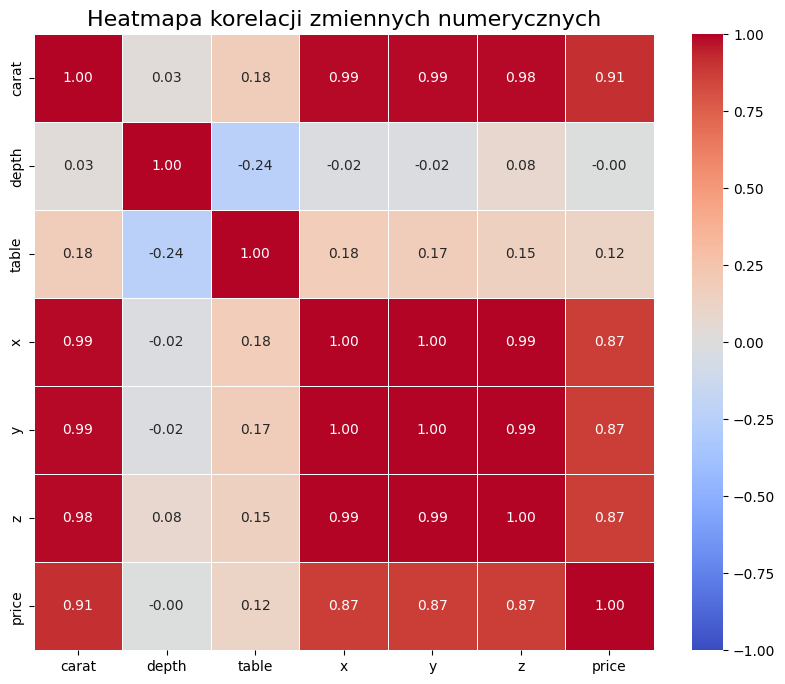

In [48]:
corr_matrix = df_pd[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Heatmapa korelacji zmiennych numerycznych', fontsize=16)
plt.show()

### Wnioski końcowe z procesu trenowania i ewaluacji
1. Skuteczność czyszczenia danych (Usuwanie outlierów)

    Proces oczyszczania danych za pomocą metody rozstępu międzykwartylowego (IQR) zidentyfikował i usunął 4849 skrajnych przypadków, co stanowi około 9% początkowego zbioru danych. Pozbycie się tych anomalii pozwoliło na ustabilizowanie modelu. Dzięki temu algorytm nie próbował dopasowywać się do rynkowych ekstremów, lecz skupił się na głównych trendach, co przełożyło się na wysoką dokładność predykcji.

2. Wpływ ilości danych na wydajność modelu (Batch Training)

    Eksperyment z trenowaniem modelu na rosnących podzbiorach danych treningowych pokazał wyraźną i logiczną zależność:



    *   Trend rosnący: Wraz ze wzrostem ilości danych, model stawał się coraz dokładniejszy. Błąd RMSE spadł z 1086 (dla 20% danych) do 1051 (dla 100% danych), a współczynnik R2 wzrósł z 0.8996 do 0.9059.
    *   Zjawisko nasycenia (Plateau): Największy skok jakościowy widać między 40% a 60% objętości danych (spadek RMSE o niemal 20 jednostek). Z kolei różnica między wynikiem dla 80% a 100% danych jest już bardzo niewielka. Oznacza to, że dla tego zestawu cech model osiągnął swój limit możliwości i dokładanie kolejnych dziesiątek tysięcy wierszy przyniosłoby już tylko marginalne korzyści.
    *    Szybkość predykcji: Czas wykonywania samej predykcji na zbiorze testowym utrzymywał się na stabilnym i bardzo szybkim poziomie (około 0.9 – 1.2 sekundy), co dowodzi, że model świetnie nadaje się do szybkiego wnioskowania na nowych danych.

3. Sukces redukcji wymiarowości (Feature Selection)

    Model uproszczony, z którego usunięto najsłabiej skorelowane cechy (proporcje depth i table), osiągnął wyniki niemal identyczne z pełnym modelem trenowanym na 100% danych:

  RMSE: 1054.51 (względem 1051.39 dla pełnego modelu).

  R2: 0.9053 (względem 0.9059 dla pełnego modelu).

In [49]:
import time
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

print("Rozpoczęcie treningu modelu uproszczonego (bez 'depth' i 'table')...")

# 1. Definicja kolumn - odrzucamy 'depth' i 'table'
categorical_cols = ['cut', 'color', 'clarity']
# Wykluczamy zmienną docelową oraz nasze dwie najsłabsze cechy
numerical_cols_reduced = [col for col in df_spark.columns if col not in categorical_cols + ['price', 'depth', 'table']]

# 2. Tworzenie Pipeline'u dla zredukowanego zbioru danych
indexers_red = [StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep") for col in categorical_cols]
encoders_red = [OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded") for col in categorical_cols]
assembler_inputs_red = [col + "_encoded" for col in categorical_cols] + numerical_cols_reduced
vector_assembler_red = VectorAssembler(inputCols=assembler_inputs_red, outputCol="features_reduced")

pipeline_red = Pipeline(stages=indexers_red + encoders_red + [vector_assembler_red])
df_transformed_red = pipeline_red.fit(df_spark).transform(df_spark)

# 3. Podział danych
(train_red, test_red) = df_transformed_red.randomSplit([0.8, 0.2], seed=42)

# 4. Inicjalizacja i trening modelu z pomiarem czasu
rf_red = RandomForestRegressor(featuresCol="features_reduced", labelCol="price", seed=42)

start_time_red = time.time()
rf_model_red = rf_red.fit(train_red)
end_time_red = time.time()

training_duration_red = end_time_red - start_time_red

# 5. Predykcja i Ewaluacja
predictions_red = rf_model_red.transform(test_red)

evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse_red = evaluator_rmse.evaluate(predictions_red)
r2_red = evaluator_r2.evaluate(predictions_red)

print("\n=== WYNIKI MODELU ZREDUKOWANEGO ===")
print(f"Czas treningu: {training_duration_red:.2f} sekund")
print(f"RMSE: {rmse_red:.2f}")
print(f"R-squared (R2): {r2_red:.4f}")

Rozpoczęcie treningu modelu uproszczonego (bez 'depth' i 'table')...

=== WYNIKI MODELU ZREDUKOWANEGO ===
Czas treningu: 6.84 sekund
RMSE: 1054.51
R-squared (R2): 0.9053
